# Head

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnf
import torch.nn as nn

class MLP(nn.Module):
    ''' Simple MLP with ReLU activations (variable number of hidden layers) '''

    def __init__(self, input_dim, output_dim, hidden_dim, n_layers=2):
        super(MLP, self).__init__()

        layers = []
        
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        
        layers.append(nn.Linear(hidden_dim, output_dim))
        
        self.nn = nn.Sequential(*layers)

    def forward(self, x):
        return self.nn(x)
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"\tGPU: {torch.cuda.get_device_name(0)}")
    print(f"\tCUDA Version: {torch.version.cuda}")

Using device: cuda
	GPU: NVIDIA GeForce RTX 3060
	CUDA Version: 12.1


# Variance reduction techniques

## Importance sampling

### Problem 1.

Normal distribution with unknown mean and unknown variance. Priors:
$$\begin{align}
\mu &\sim \mathcal{N}(\mu_0, \sigma_0^2) \\
\sigma^2 &\sim \mathcal{U}(0, A)
\end{align}$$


In [40]:
sigma0 = 1
mu0 = 0

A = 5
k = 1000 # number of datasets
n = 64 # samples per dataset

np.random.seed(0)

sigmas = np.random.uniform(0, A, size=k)
mus = np.random.normal(mu0, sigma0, size=k)

X = np.random.normal(mus[:, None], sigmas[:, None], size=(k, n))

We want to backwards derive the posterior mean estimator for $\mu$ and $\sigma^2$ using a neural network with the DeepSets architecture.

In [41]:
# Basic Deepsets Neural network
class PosteriorMeanEstimator(nn.Module):
    def __init__(self,
        summary_stats=32,
        summary_width=32,
        estimator_width=32):
        
        super().__init__()

        self.mlp_point = MLP(
            input_dim=1, 
            output_dim=summary_stats, 
            hidden_dim=summary_width,
            n_layers=2)

        self.mlp_aggregate = MLP(
            input_dim=summary_stats, 
            output_dim=2,
            hidden_dim=estimator_width,
            n_layers=2)

    def forward(self, x):
        # normalize input
        # x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)

        x = x.unsqueeze(-1).float()  # (batch_size, n, 1)
        summaries = self.mlp_point(x)  # (batch_size, n, summary_stats)
        H = summaries.sum(dim=1)  # (batch_size, summary_stats)
        out = self.mlp_aggregate(H)  # (batch_size, 2)

        # assume output of form (mu, sigma)
        mu_hat = out[:, 0]
        sigma_hat = nnf.softplus(out[:, 1])

        return torch.stack([mu_hat, sigma_hat], dim=1)


In [42]:
def sample_batch(batch_size, mu0, sigma0, A, n):
    mu_batch = torch.from_numpy(np.random.normal(mu0, sigma0, size=batch_size)).float()
    sigma_batch = torch.from_numpy(np.random.uniform(0, A, size=batch_size)).float()
    
    x_batch = torch.zeros(batch_size, n)
    for i in range(batch_size):
        x_batch[i] = torch.from_numpy(
            np.random.normal(mu_batch[i].item(), sigma_batch[i].item(), size=n)
        ).float()
    
    theta_batch = torch.stack([mu_batch, sigma_batch], dim=1)
    return theta_batch, x_batch


theta_test, x_test = sample_batch(1024, mu0, sigma0, A, n)
x_test = x_test.to(device)
theta_test = theta_test.to(device)

neural_estimator = PosteriorMeanEstimator(
    summary_stats=32,
    summary_width=32,
    estimator_width=32
).to(device)

loss_fn = torch.nn.MSELoss() 
test_output = neural_estimator(x_test)
test_loss = loss_fn(test_output, theta_test)
print(f"Initial test loss: {test_loss:.4f}")

Initial test loss: 4.0091


Epoch 8/64, Train Loss: 0.2539, Test Loss: 0.2269
Epoch 16/64, Train Loss: 0.1274, Test Loss: 0.1247
Epoch 24/64, Train Loss: 0.1104, Test Loss: 0.1045
Epoch 32/64, Train Loss: 0.1015, Test Loss: 0.0967
Epoch 40/64, Train Loss: 0.0970, Test Loss: 0.0932
Epoch 48/64, Train Loss: 0.0939, Test Loss: 0.0913
Epoch 56/64, Train Loss: 0.0934, Test Loss: 0.0901
Epoch 64/64, Train Loss: 0.0927, Test Loss: 0.0896


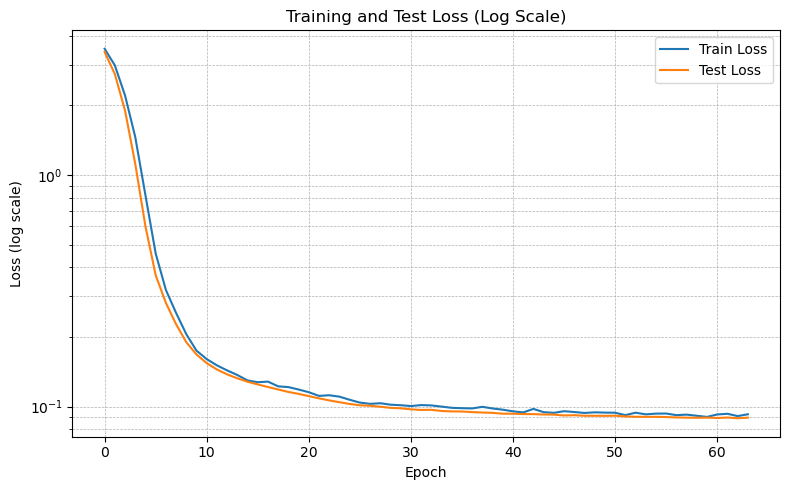

In [43]:
n_epochs = 64
n_batches_per_epoch = 128
training_batch_size = 128

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(neural_estimator.parameters(), lr=0.00001)


train_losses = []
test_losses = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    
    for batch_idx in range(n_batches_per_epoch):
        theta_batch, x_batch = sample_batch(training_batch_size, mu0, sigma0, A, n)
        x_batch = x_batch.to(device)
        theta_batch = theta_batch.to(device)
        
        optimizer.zero_grad()
        theta_pred = neural_estimator(x_batch)
        loss = loss_fn(theta_pred, theta_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_epoch_loss = epoch_loss / n_batches_per_epoch
    train_losses.append(avg_epoch_loss)
    
    with torch.no_grad():
        theta_pred_test = neural_estimator(x_test)
        test_loss = loss_fn(theta_pred_test, theta_test).item()
        test_losses.append(test_loss)
    
    if (epoch + 1) % 8 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_epoch_loss:.4f}, Test Loss: {test_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.yscale('log')  # Set y-axis to log scale
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training and Test Loss (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.show()

Final Test MSE: 0.0896


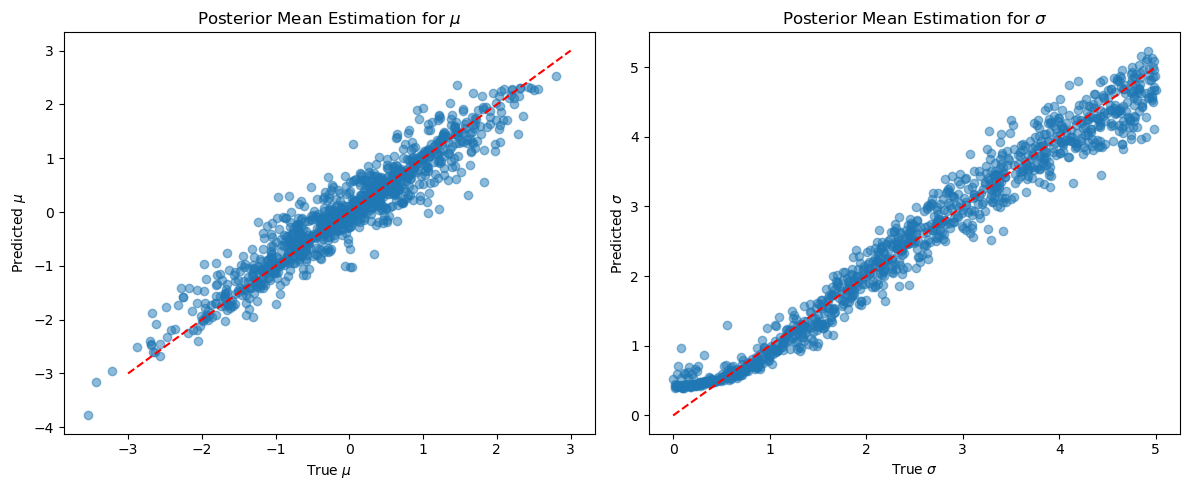

In [44]:
# plot the test predictions vs true values
with torch.no_grad():
    theta_pred_test = neural_estimator(x_test).cpu().numpy()
    theta_test_np = theta_test.cpu().numpy()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.scatter(theta_test_np[:, 0], theta_pred_test[:, 0], alpha=0.5)
plt.plot([mu0 - 3*sigma0, mu0 + 3*sigma0], [mu0 - 3*sigma0, mu0 + 3*sigma0], 'r--')  # y=x line
plt.xlabel('True $\mu$')
plt.ylabel('Predicted $\mu$')
plt.title('Posterior Mean Estimation for $\mu$')

plt.subplot(1, 2, 2)
plt.scatter(theta_test_np[:, 1], theta_pred_test[:, 1], alpha=0.5)
plt.plot([0, A], [0, A], 'r--')  # y=x line
plt.xlabel('True $\sigma$')
plt.ylabel('Predicted $\sigma$')
plt.title('Posterior Mean Estimation for $\sigma$')
plt.tight_layout()

print(f"Final Test MSE: {test_loss:.4f}")

Now with importance sampling small sigma. Lets instead sample from a beta()

In [45]:
def sample_from_proposal(batch_size, alpha_sigma, beta_sigma, A, device='cpu'):
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32, device=device)
    return sigma

def compute_importance_weights(sigma, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(sigma):
        sigma = sigma.cpu().numpy()
    sigma_tilde = sigma / A
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    p_theta = 1.0 / (2 * A)
    return p_theta / (q_sigma)



In [46]:
neural_estimator_IS = PosteriorMeanEstimator(
    summary_stats=32,
    summary_width=32,
    estimator_width=32
).to(device)

alpha_sigma, beta_sigma = 2, 5
optimizer_IS = torch.optim.Adam(neural_estimator_IS.parameters(), lr=0.00001)

def sample_batch_IS(batch_size, mu0, sigma0, alpha_sigma, beta_sigma, A, n):
    mu_batch = torch.tensor(np.random.normal(mu0, sigma0, size=batch_size), dtype=torch.float32)
    sigma_batch = sample_from_proposal(batch_size, alpha_sigma, beta_sigma, A)

    x_batch = torch.zeros(batch_size, n)
    for i in range(batch_size):
        x_batch[i] = torch.tensor(
            np.random.normal(mu_batch[i].item(), sigma_batch[i].item(), size=n),
            dtype=torch.float32
        )

    theta_batch = torch.stack([mu_batch, sigma_batch], dim=1)
    weights = torch.tensor(
        compute_importance_weights(sigma_batch, alpha_sigma, beta_sigma, A),
        dtype=torch.float32
    )
    return theta_batch, x_batch, weights

train_losses_IS = []
test_losses_IS = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for _ in range(n_batches_per_epoch):
        theta_batch, x_batch, weights = sample_batch_IS(
            training_batch_size, mu0, sigma0, alpha_sigma, beta_sigma, A, n
        )
        x_batch, theta_batch, weights = x_batch.to(device), theta_batch.to(device), weights.to(device)

        optimizer_IS.zero_grad()
        theta_pred = neural_estimator_IS(x_batch)

        # IS-weighted MSE: reweight each sample to correct for proposal
        sq_err = ((theta_pred - theta_batch) ** 2).sum(dim=1)
        loss = (weights * sq_err).mean()
        loss.backward()
        optimizer_IS.step()

        epoch_loss += loss.item()

    train_losses_IS.append(epoch_loss / n_batches_per_epoch)

    # Test loss: standard MSE on uniformly sampled test set (fair comparison)
    with torch.no_grad():
        pred = neural_estimator_IS(x_test)
        test_losses_IS.append(loss_fn(pred, theta_test).item())

    if (epoch + 1) % 8 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train: {train_losses_IS[-1]:.4f}, Test MSE: {test_losses_IS[-1]:.4f}")

Epoch 8/64, Train: 2.2040, Test MSE: 2.8325
Epoch 16/64, Train: 0.7248, Test MSE: 0.7221
Epoch 24/64, Train: 0.2121, Test MSE: 0.2858
Epoch 32/64, Train: 0.1539, Test MSE: 0.1807
Epoch 40/64, Train: 0.1226, Test MSE: 0.1385
Epoch 48/64, Train: 0.1280, Test MSE: 0.1211
Epoch 56/64, Train: 0.0927, Test MSE: 0.1163
Epoch 64/64, Train: 0.1056, Test MSE: 0.1246


In [47]:
with torch.no_grad():
    pred_base = neural_estimator(x_test).cpu().numpy()
    pred_IS = neural_estimator_IS(x_test).cpu().numpy()
    true_vals = theta_test.cpu().numpy()

mse_mu_base = np.mean((pred_base[:, 0] - true_vals[:, 0])**2)
mse_sig_base = np.mean((pred_base[:, 1] - true_vals[:, 1])**2)
mse_mu_IS = np.mean((pred_IS[:, 0] - true_vals[:, 0])**2)
mse_sig_IS = np.mean((pred_IS[:, 1] - true_vals[:, 1])**2)

print(f"{'':20s} {'Baseline':>10s} {'IS':>10s}")
print(f"{'MSE (mu)':20s} {mse_mu_base:10.4f} {mse_mu_IS:10.4f}")
print(f"{'MSE (sigma)':20s} {mse_sig_base:10.4f} {mse_sig_IS:10.4f}")
print(f"{'MSE (total)':20s} {mse_mu_base+mse_sig_base:10.4f} {mse_mu_IS+mse_sig_IS:10.4f}")

                       Baseline         IS
MSE (mu)                 0.1111     0.1427
MSE (sigma)              0.0681     0.1066
MSE (total)              0.1792     0.2493


In [48]:
# IS Neural Estimator
neural_estimator_IS = PosteriorMeanEstimator(
    summary_stats=32,
    summary_width=32,
    estimator_width=32
).to(device)

alpha_sigma, beta_sigma = 0.7, 1  # beta params that emphasise small sigma

optimizer_IS = torch.optim.Adam(neural_estimator_IS.parameters(), lr=0.00001)

def sample_batch_IS(batch_size, mu0, sigma0, alpha_sigma, beta_sigma, A, n):
    mu_batch = torch.tensor(np.random.normal(mu0, sigma0, size=batch_size),dtype=torch.float32)
    sigma_batch = sample_from_proposal(batch_size, alpha_sigma, beta_sigma, A)

    x_batch = torch.zeros(batch_size, n)
    for i in range(batch_size):
        x_batch[i] = torch.tensor(
            np.random.normal(mu_batch[i].item(), sigma_batch[i].item(), size=n),
            dtype=torch.float32
        )

    theta_batch = torch.stack([mu_batch, sigma_batch], dim=1)
    weights = compute_importance_weights(sigma_batch, alpha_sigma, beta_sigma, A)
    weights = torch.tensor(weights, dtype=torch.float32)
    return theta_batch, x_batch, weights

train_losses_IS = []
test_losses_IS = []

for epoch in range(n_epochs):
    epoch_loss = 0.0
    for batch_idx in range(n_batches_per_epoch):
        theta_batch, x_batch, weights = sample_batch_IS(
            training_batch_size, mu0, sigma0, alpha_sigma, beta_sigma, A, n
        )
        x_batch = x_batch.to(device)
        theta_batch = theta_batch.to(device)
        weights = weights.to(device)

        optimizer_IS.zero_grad()
        theta_pred = neural_estimator_IS(x_batch)

        # weighted MSE loss
        sq_err = ((theta_pred - theta_batch) ** 2).sum(dim=1)
        loss = (weights * sq_err).mean()
        loss.backward()
        optimizer_IS.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / n_batches_per_epoch
    train_losses_IS.append(avg_epoch_loss)

    with torch.no_grad():
        theta_pred_test = neural_estimator_IS(x_test)
        test_loss_IS = loss_fn(theta_pred_test, theta_test).item()
        test_losses_IS.append(test_loss_IS)

    if (epoch + 1) % 8 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_epoch_loss:.4f}, Test Loss:      {test_loss_IS:.4f}")

Epoch 8/64, Train Loss: 0.2836, Test Loss:      0.2686
Epoch 16/64, Train Loss: 0.1445, Test Loss:      0.1359
Epoch 24/64, Train Loss: 0.1178, Test Loss:      0.1129
Epoch 32/64, Train Loss: 0.1079, Test Loss:      0.1033
Epoch 40/64, Train Loss: 0.1032, Test Loss:      0.0997
Epoch 48/64, Train Loss: 0.0973, Test Loss:      0.0965
Epoch 56/64, Train Loss: 0.0959, Test Loss:      0.0946
Epoch 64/64, Train Loss: 0.0961, Test Loss:      0.0933


                       Baseline         IS
MSE (mu)                 0.1111     0.1074
MSE (sigma)              0.0681     0.0792
MSE (total)              0.1792    0.1866


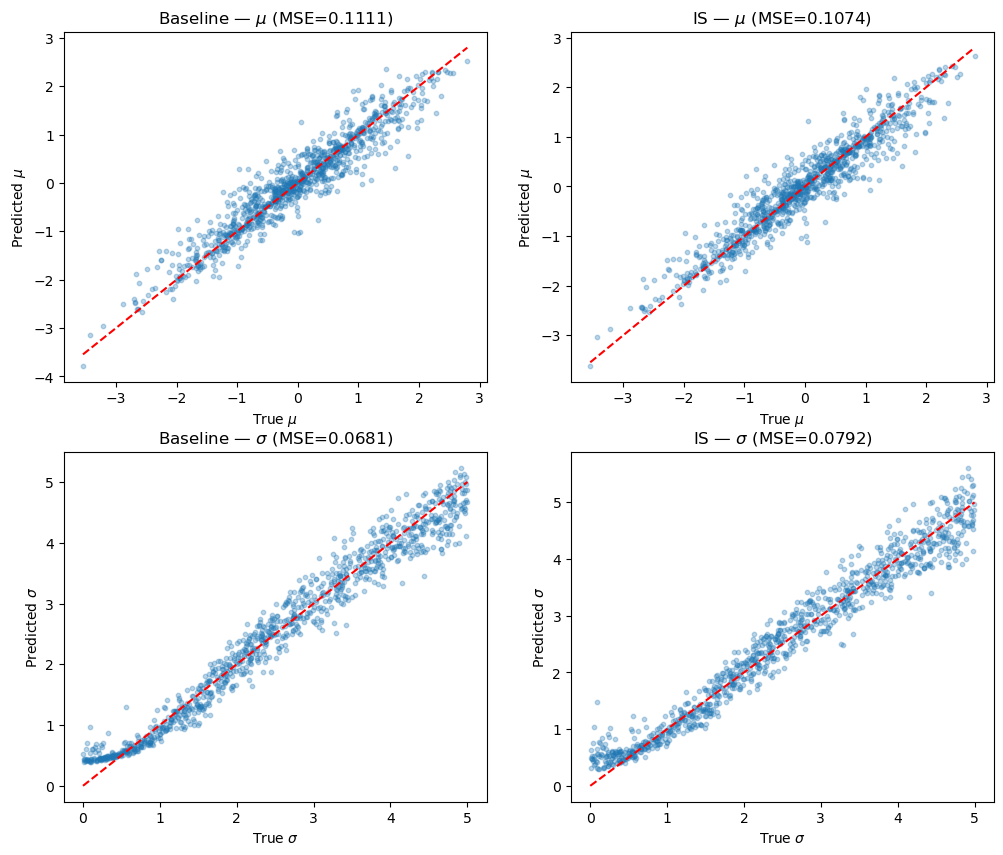

In [49]:
with torch.no_grad():
    pred_baseline = neural_estimator(x_test).cpu().numpy()
    pred_IS = neural_estimator_IS(x_test).cpu().numpy()
    true_vals = theta_test.cpu().numpy()

mse_mu_base = np.mean((pred_baseline[:, 0] - true_vals[:, 0])**2)
mse_sigma_base = np.mean((pred_baseline[:, 1] - true_vals[:, 1])**2)

mse_mu_IS = np.mean((pred_IS[:, 0] - true_vals[:, 0])**2)
mse_sigma_IS = np.mean((pred_IS[:, 1] - true_vals[:, 1])**2)

print(f"{'':20s} {'Baseline':>10s} {'IS':>10s}")
print(f"{'MSE (mu)':20s} {mse_mu_base:10.4f} {mse_mu_IS:10.4f}")
print(f"{'MSE (sigma)':20s} {mse_sigma_base:10.4f} {mse_sigma_IS:10.4f}")
print(f"{'MSE (total)':20s} {mse_mu_base+mse_sigma_base:10.4f}{mse_mu_IS+mse_sigma_IS:10.4f}")

# Scatter plots side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (name, pred) in enumerate([("Baseline", pred_baseline), ("IS", pred_IS)]):
    axes[0, col].scatter(true_vals[:, 0], pred[:, 0], alpha=0.3, s=10)
    axes[0, col].plot([true_vals[:, 0].min(), true_vals[:, 0].max()],
                    [true_vals[:, 0].min(), true_vals[:, 0].max()], 'r--')
    axes[0, col].set_xlabel('True $\\mu$')
    axes[0, col].set_ylabel('Predicted $\\mu$')
    axes[0, col].set_title(f'{name} — $\\mu$ (MSE={mse_mu_base if col==0 else mse_mu_IS:.4f})')

    axes[1, col].scatter(true_vals[:, 1], pred[:, 1], alpha=0.3, s=10)
    axes[1, col].plot([0, A], [0, A], 'r--')
    axes[1, col].set_xlabel('True $\\sigma$')
    axes[1, col].set_ylabel('Predicted $\\sigma$')
    axes[1, col].set_title(f'{name} — $\\sigma$ (MSE={mse_sigma_base if col==0 else mse_sigma_IS:.4f})')

## Control variates

The idea is when we have another correlated random variable with known mean, we can use it to reduce the variance of our estimator.

## Blackwellization

### General

Suppose we are interested in estimating $\mathbb{E}[\vec\theta]$ for some random variable $\vec\theta$. Naively, we could use the Monte Carlo estimator:
$$\hat{\vec\theta}_{MC} = \frac{1}{N} \sum_{i=1}^N \vec\theta_i,$$

where $\vec\theta_1, \ldots, \vec\theta_N$ are i.i.d. samples from the distribution of $\vec\theta$.


Alternatively, If we know some conditional expectation of one of the random variables conditioned on another, we can use this to reduce the variance of our estimator. For example, if we know analytically $\mathbb{E}[\vec\theta| \theta_1]$ for some component $\theta_1$, then we can use the following estimator:
$$\hat{\vec\theta}_{BW} = \frac{1}{N} \sum_{i=1}^N \mathbb{E}[\vec\theta| \theta_{1,i}],$$

And we are guaranteed that $\text{Var}(\hat{\vec\theta}_{BW}) \leq \text{Var}(\hat{\vec\theta}_{MC})$.

### Application
The goal is to minimise the MSE by training our model $f_\lambda(Y)$. ie:
$$
\min_\lambda \mathbb{E}[(f_\lambda(Y) - X)^2]
$$

We have 
$$
\begin{align}
 MSE &=  (f_\lambda (Y) - \theta) ^T (f_\lambda (Y) - \theta) \\
&= f_\lambda (Y)^T f_\lambda (Y) - 2 \theta^T f_\lambda (Y) + \theta^T \theta \\


\end{align}
$$

In expectation this becomes:
$$
\begin{align}
\mathbb{E}[MSE \, | \,Y] &= \mathbb{E}[f_\lambda (Y)^T f_\lambda (Y) - 2 \theta^T f_\lambda (Y) + \theta^T \theta \, | \, Y] \\
&= f_\lambda (Y)^T f_\lambda (Y) - 2f_\lambda (Y)\cdot \mathbb{E}[\theta^T  \, | \, Y] + \mathbb{E}[\theta^T \theta \, | \, Y] \\

\end{align}
$$


The idea is that we can possibly partition $\theta$ into two parts, $\theta = (\theta_1, \vec{\theta})$, where $\theta_1$ is the part of $\theta$ that is most correlated with $Y$. First we will analyse the case where we can destermine both $\mathbb{E}[\theta^T \theta \, | \, Y]$ and $\mathbb{E}[\theta^T  \, | \, Y]$. (later we can look at the case where we can only determine $\mathbb{E}[\theta^T  \, | \, Y]$)

### problem 1.



Assume a bayesian normal setting where:
$$
\begin{align}
\vec \beta &\sim \mathcal{N}(\vec \beta_0, \Sigma_0) \\
Y &\sim \mathcal{N}(X\vec \beta, \Sigma)
\end{align}
$$
We want to find the optimal estimator for $\vec \beta$ given $Y$. We can use the fact that the posterior distribution of $\vec \beta$ is also normal, and we can compute the mean and covariance of this distribution analytically. The posterior mean is given by:
$$\begin{align}
\mathbb{E}[\vec \beta | Y] &=  (X^T \Sigma^{-1} X + \Sigma_0^{-1})^{-1}(X^T \Sigma^{-1} Y + \Sigma_0^{-1} \vec \beta_0) \\
\Sigma_{post} &= (X^T \Sigma^{-1} X + \Sigma_0^{-1})^{-1}
\end{align}
$$



$$
\begin{align}
\hat \beta_{MC} &= \frac{1}{N} \sum_{i=1}^N \vec \beta_i \\
\hat \beta_{BW} &= \frac{1}{N} \sum_{i=1}^N \mathbb{E}[\vec \beta | Y_i] = \frac{1}{N} \sum_{i=1}^N \Sigma_{post} (X^T \Sigma^{-1} Y_i + \Sigma_0^{-1} \vec \beta_0)
\end{align}
    
$$

For now lets just assume $\Sigma = \sigma^2 I$ and $\Sigma_0 = \sigma_0^2 I$. Then we have:
$$
\begin{align}
\hat \beta_{BW} &= \frac{1}{N} \sum_{i=1}^N \Sigma_{post} (X^T \Sigma^{-1} Y_i + \Sigma_0^{-1} \vec \beta_0) \\
&= \frac{1}{N} \sum_{i=1}^N (X^T \Sigma^{-1} X + \Sigma_0^{-1})^{-1}(X^T \Sigma^{-1} Y_i + \Sigma_0^{-1} \vec \beta_0) \\
&= \frac{1}{N} \sum_{i=1}^N (\frac{1}{\sigma^2} X^T X + \frac{1}{\sigma_0^2} I)^{-1}(\frac{1}{\sigma^2} X^T Y_i + \frac{1}{\sigma_0^2} \vec \beta_0) 
\end{align}
$$

### Comparison of variances

First, let us do the 